In [23]:
# Importamos las librerías básicas

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# modificamos la configuración para ver todas las columnas al mostrar dataframes
pd.set_option("display.max_columns", None)

# Bank dataset

In [2]:
# Cargamos datos limpiosde nuestro primer dataset
bank_df = pd.read_csv ('../Data/DataProcessed/bank-additional-clean.csv', sep=",")
# Hacemos una copia para trabajar con ella
df_bank = bank_df.copy()

Creamos la función null_values para poder reutilizarla en cualquier dataframe

In [3]:
def null_values(dataframe, only_nulls: bool = False):
    """
    Genera un DataFrame con el conteo y porcentaje de valores nulos por columna.
    
    Parámetros:
    -----------
    dataframe : pd.DataFrame
        DataFrame de entrada.
    only_nulls : bool, opcional (default=False)
        Si True, devuelve únicamente las columnas con al menos un nulo.
    
    Devuelve:
    ---------
    df_null : pd.DataFrame
        DataFrame con columnas:
            - null_counts : número de nulos
            - null_% : porcentaje de nulos sobre el total
    """
    null_counts = dataframe.isnull().sum()
    null_percent = (null_counts / dataframe.shape[0] * 100).round(2)
    df_null = pd.DataFrame({
        "null_counts": null_counts,
        "null_%": null_percent
    })

    if only_nulls:
        df_null = df_null[df_null["null_counts"] > 0]
    
    return df_null


In [4]:
df_null = null_values(df_bank)
#Para obtener un resumen ordenado de mayor a menor de nulos
display(df_null.sort_values("null_%", ascending=False))

,null_counts,null_%
euribor3m,9256,21.53
default,8981,20.89
age,5120,11.91
education,1807,4.20
loan,1026,2.39
housing,1026,2.39
cons.price.idx,471,1.10
job,345,0.80
contact_year,248,0.58
contact_month,248,0.58


In [5]:
# Solo que muestre columnas con nulos
df_null= null_values(df_bank, only_nulls=True)
display(df_null.sort_values("null_%", ascending=False))

,null_counts,null_%
euribor3m,9256,21.53
default,8981,20.89
age,5120,11.91
education,1807,4.20
loan,1026,2.39
housing,1026,2.39
cons.price.idx,471,1.10
job,345,0.80
contact_month,248,0.58
date,248,0.58


### Vamos a tratar los nulos en el orden de la lista anterior, es decir, primero trataremos aquellos con mayor porcentaje de nulos

## Nulos de euribor3m

In [6]:
#Obtenemos un dataframe que solo tiene valores nulos de euribor3m
df_bank_euribornull = df_bank[df_bank['euribor3m'].isna()]
df_bank_euribornull.sample(5)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,contact_month,contact_year
28809,36.0,entrepreneur,MARRIED,university.degree,no,yes,no,cellular,486,2,999,0,NONEXISTENT,-1.8,93.075,-47.1,NaN,5099,no,2017-08-19,26.494,-86.042,3ccc4efd-ae03-4f3a-80db-5a2656928194,August,2017.0
21245,44.0,blue-collar,MARRIED,basic.9y,NaN,yes,no,cellular,312,3,999,0,NONEXISTENT,1.4,93.444,-36.1,NaN,5228,no,2019-10-20,31.522,-105.587,999f2e0d-d4b0-47d4-965f-7cb2ae449319,October,2019.0
39788,51.0,admin.,MARRIED,university.degree,no,yes,no,cellular,281,3,10,3,SUCCESS,-1.7,94.055,-39.8,NaN,4991,yes,2018-04-11,34.866,-78.896,d1d0a2f9-c2ad-4040-80e4-3138e20c70f5,April,2018.0
2495,51.0,self-employed,MARRIED,professional.course,NaN,yes,yes,telephone,139,4,999,0,NONEXISTENT,1.1,93.994,-36.4,NaN,5191,no,2018-12-05,35.026,-69.354,54336930-feb5-4d85-a72a-d4094522485f,December,2018.0
32296,37.0,blue-collar,MARRIED,high.school,NaN,no,no,cellular,323,2,999,1,FAILURE,-1.8,92.893,-46.2,NaN,5099,no,2018-05-10,29.966,-84.530,611708de-8081-4fc4-beab-4d23bbeba7bc,May,2018.0


In [7]:
df_bank_euribornull['date'].unique

<bound method Series.unique of 1        2016-09-14
3        2015-11-29
4        2017-01-29
9        2016-11-02
11       2016-04-17
            ...    
42992    2016-03-23
42993    2018-04-04
42995    2015-10-13
42996    2018-03-17
42997    2016-09-15
Name: date, Length: 9256, dtype: object>

In [8]:
df_bank[df_bank['date']=='2017-01-29'].sample(5)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,contact_month,contact_year
19530,50.0,technician,MARRIED,professional.course,no,no,no,cellular,139,2,999,0,NONEXISTENT,1.4,93.444,-36.1,NaN,5228,no,2017-01-29,29.894,-105.792,90c7eb66-4a75-4ece-ab25-4389a8d7928e,January,2017.0
3535,33.0,services,MARRIED,high.school,no,yes,no,telephone,211,2,999,0,NONEXISTENT,1.1,93.994,-36.4,4.859,5191,no,2017-01-29,32.200,-98.931,fe0cdbbd-2a90-4dd6-bb90-4b211470ee5d,January,2017.0
23135,37.0,blue-collar,SINGLE,professional.course,no,no,no,cellular,109,11,999,0,NONEXISTENT,1.4,93.444,-36.1,4.965,5228,no,2017-01-29,30.668,-89.740,5e270c34-cb11-49ed-b76a-91a7680440c1,January,2017.0
19622,45.0,technician,MARRIED,university.degree,no,no,no,telephone,430,3,999,0,NONEXISTENT,1.4,93.444,-36.1,4.968,5228,no,2017-01-29,27.539,-84.888,8e363035-cf9f-4a24-a17d-e3e6bc3ee024,January,2017.0
16511,33.0,blue-collar,MARRIED,basic.9y,NaN,no,no,cellular,218,3,999,0,NONEXISTENT,1.4,93.918,-42.7,4.963,5228,no,2017-01-29,40.857,-71.679,64a7910b-94f7-48cc-a892-de5fa8055292,January,2017.0


Hemos obtenido un data frame que contiene únicamente los registros con un valor de euribor3m nulo para realizar una inspección. Hemos identificado diferentes fechas que tienen valores nulos de euribor3m asociados. Hemos vuelto al data frame original para buscar algunas de estas fechas y ver si nos pueden dar una estmiación del euribor3m en ese momento pero el propio dataframe presenta diferentes valores de euribor3m para una misma fecha lo que creo que es una insconsistencia.

Para cada fecha, vemos cuántos valores diferentes de euribor3m existen:

In [9]:
df_bank.groupby('date')['euribor3m'].nunique().sort_values(ascending=False)


date
2016-02-28    44
2017-02-28    44
2018-02-28    37
2015-02-28    36
2019-02-28    35
              ..
2019-08-10     6
2016-09-28     6
2017-02-18     6
2018-10-23     6
2015-09-17     5
Name: euribor3m, Length: 1825, dtype: int64

Comprobamos que efectivamente hay distintos valores de euribor3m para una misma fecha

Vamos a utilizar la media por fecha

Para cada fecha, reemplazaremos los valores nulos por la media 
de los valores existentes para esa fecha.

In [10]:
def rellenar_euribor3m_por_fecha(df, col_date='date', col_euribor='euribor3m'):
    """
    Rellena los valores nulos de la columna euribor3m usando la media de la misma fecha.

    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame original con los datos.
    col_date : str
        Nombre de la columna que contiene la fecha (por defecto 'date').
    col_euribor : str
        Nombre de la columna de euribor a rellenar (por defecto 'euribor3m').

    Devuelve:
    ---------
    df_rellenado : pd.DataFrame
        DataFrame con los valores nulos de euribor3m rellenados.
    """
    # Nos aseguramos de que la columna de fecha es datetime
    df[col_date] = pd.to_datetime(df[col_date])

    # Calculamos la media del euribor3m por fecha
    euribor_por_fecha = df.groupby(col_date)[col_euribor].mean()

    # Rellenamos los nulos usando la media de la fecha
    df_rellenado = df.copy()
    df_rellenado[col_euribor] = df_rellenado[col_euribor].fillna(df_rellenado[col_date].map(euribor_por_fecha)).round(3)

# Si euribor3m es nulo → se reemplaza por la media de la fecha.
# Si euribor3m tiene valor → se mantiene ese valor.

    return df_rellenado


In [11]:
# Llamamos a la función
df_bank_euribor3m_rellenado = rellenar_euribor3m_por_fecha(df_bank)

# Verificamos que ya no hay nulos en euribor3m
print(df_bank_euribor3m_rellenado['euribor3m'].isnull().sum())


57


Hemos pasado de 9256 a 57 nulos. Puede que los que no se hayan rellenado sea porque no tienen ninguna fecha asociada. Vamos a comprobarlo

In [12]:
df_bank_euribor3m_rellenado[df_bank_euribor3m_rellenado['euribor3m'].isna()].sample(5)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,contact_month,contact_year
41222,50.0,technician,MARRIED,professional.course,no,no,yes,cellular,166,1,999,0,NONEXISTENT,-0.1,93.200,-42.0,NaN,5195,no,NaT,38.811,-83.102,7a832f0a-aaa8-4581-a8aa-c562a96e7a38,NaN,NaN
20541,35.0,technician,MARRIED,university.degree,no,yes,no,cellular,455,1,999,0,NONEXISTENT,1.4,93.444,-36.1,NaN,5228,yes,NaT,25.619,-84.711,2af96f93-7144-4754-a811-274916d672e7,NaN,NaN
23868,52.0,blue-collar,MARRIED,basic.9y,no,no,no,cellular,85,8,999,0,NONEXISTENT,1.4,93.444,-36.1,NaN,5228,no,NaT,27.267,-109.626,c2af5d15-a22f-411e-bb6c-82f34cbd1e84,NaN,NaN
24926,29.0,management,SINGLE,university.degree,no,no,no,cellular,232,1,999,1,FAILURE,-0.1,93.200,-42.0,NaN,5195,no,NaT,47.146,-67.600,f03b408f-0246-4c03-b219-2560cdb00940,NaN,NaN
32764,27.0,NaN,SINGLE,high.school,NaN,yes,no,cellular,334,2,999,0,NONEXISTENT,-1.8,92.893,-46.2,NaN,5099,no,NaT,33.429,-68.199,84100121-c9c0-49c8-afec-41ce17a48eb9,NaN,NaN


Comprobado, estos los dejaremos como nulos por ser un porcentaje muy pequeño.

## Nulos de la columna default

In [ ]:
#Obtenemos un dataframe que solo tiene valores nulos de default
df_bank_default_null = df_bank[df_bank['default'].isna()]
df_bank_default_null.sample(5)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,contact_month,contact_year
589,54.0,retired,MARRIED,high.school,NaN,yes,no,telephone,412,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191,no,2015-04-16,30.193,-113.786,15433b13-8b50-4d3b-a987-b3e8315e5983,April,2015.0
9170,41.0,blue-collar,MARRIED,basic.9y,NaN,yes,no,telephone,326,1,999,0,NONEXISTENT,1.4,94.465,-41.8,4.967,5228,no,2017-11-29,29.568,-72.809,15afca05-774c-4d9a-b6c9-536e243975ff,November,2017.0
36131,36.0,unemployed,MARRIED,university.degree,NaN,yes,no,cellular,450,1,999,1,FAILURE,-2.9,92.963,-40.8,1.266,5076,no,2015-12-07,48.020,-84.689,63a91cf2-49fc-491b-9a41-a3ccde7ba153,December,2015.0
10745,NaN,blue-collar,MARRIED,NaN,NaN,no,no,telephone,503,11,999,0,NONEXISTENT,1.4,94.465,-41.8,4.962,5228,no,2016-03-11,49.125,-72.302,c35acd18-0ebb-4d88-94a4-d8f8829f916e,March,2016.0
2215,53.0,technician,MARRIED,professional.course,NaN,yes,no,telephone,383,1,999,0,NONEXISTENT,1.1,93.994,-36.4,NaN,5191,no,2016-02-27,27.519,-107.851,cb4e4fa3-516a-427b-ba0a-6f52a9adeaf1,February,2016.0


Tenemos un gran porcentaje de nulos (20.89%) y cómo no vemos ninguna relación directa de la columna default con las otras, aparentemente no podemos obtener información de si un cliente tiene algún historial de incumplimiento de pagos a no ser que hagamos un análisis más avanzado y decidamos utilizar un modelo de machine learning, entrenarlo y así predecir estos nulos. La solución más sensata es mantener nulos como categoría “unknown” para no perder información ni asumir algo incorrecto dado que posteriormente queremos realizar un EDA.

In [14]:
def rellenar_con_unknown(df, col_name):
    """
    Rellena los valores nulos de una columna con la categoría 'unknown'.

    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame original con los datos.
    col_name : str
        Nombre de la columna en la que se quieren rellenar los nulos.

    Devuelve:
    ---------
    df_filled : pd.DataFrame
        DataFrame con los nulos de la columna especificada rellenados con 'unknown'.
    """
    df_filled = df.copy()
    df_filled[col_name] = df_filled[col_name].fillna('unknown')
    return df_filled

In [15]:
# Rellenamos la columna 'default'
df_bank_default = rellenar_con_unknown(df_bank, 'default')

# Verificamos
print(df_bank_default['default'].isnull().sum())
print(df_bank_default['default'].value_counts())

0
default
no         34016
unknown     8981
yes            3
Name: count, dtype: int64


Comprobamos que hemos rellenado todos los nulos con unknown y también que para la columna default solo hay 3 registros que tienen 'yes', es decir, que solo 3 clientes tienen algún historial de incumplimiento de pagos. Podríamos pensar que seria correcto rellenar los unknown con un 'no' porque segun los datos la probabilidad de que un registro nulo sea 'yes' es muy baja pero si los nulos no son aleatorios podríamos introducir sesgo.

## Nulos de la columna age

In [19]:
# Obtenemos un dataframe que solo tiene valores nulos de age
df_bank_age_null = df_bank[df_bank['age'].isna()]
df_bank_age_null.sample(5)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,contact_month,contact_year
34725,NaN,admin.,SINGLE,high.school,no,yes,no,cellular,236,4,999,1,FAILURE,-1.8,92.893,-46.2,1.250,5099,no,2018-02-04,47.288,-88.775,55bdeadc-b72e-4fcf-ae9f-04083de436b9,February,2018.0
20953,NaN,self-employed,MARRIED,basic.9y,no,yes,no,cellular,219,7,999,0,NONEXISTENT,1.4,93.444,-36.1,4.964,5228,no,2018-08-01,45.981,-91.522,3c056379-2a42-4b6a-a1cd-336afeac9bd1,August,2018.0
24805,NaN,management,MARRIED,high.school,no,yes,no,cellular,84,1,999,0,NONEXISTENT,-0.1,93.200,-42.0,NaN,5195,no,2019-03-22,33.115,-118.192,5c2d6d23-ebfd-4a20-b31b-7f563fdca766,March,2019.0
14923,NaN,blue-collar,MARRIED,basic.9y,NaN,yes,no,telephone,151,1,999,0,NONEXISTENT,1.4,93.918,-42.7,4.958,5228,no,2017-04-01,43.039,-75.241,a982bbbd-a54b-4d54-a2b0-fa2b34f444f7,April,2017.0
5498,NaN,NaN,SINGLE,basic.9y,no,no,yes,telephone,369,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191,no,2018-08-17,38.565,-80.214,65321683-80bb-43ee-bf8f-2fa3921abb1a,August,2018.0


Dado que la edad sí es una variable importante para segmentar clientes y el porcentaje de nulos es 11,91% (ni bajo ni muy alto):

1. Revisamos la distribución de age.

2. Vemos si hay relación fuerte con job.

    - Si es así → imputamos con medias por grupo.

    - Si no → usamos la mediana global. ( Código: mediana_global_age = int(df_bank["age"].median()) = **38 años**)

In [34]:
# Calculamos mediana global de la edad
mediana_global_age = int(df_bank["age"].median())
mediana_global_age


38

In [24]:
# Relación entre age y job

# Agrupamos la columna 'age' por tipo de 'job' y calculamos los estadísticos por cada categoría de job. 
# Así sabremos si hay diferencias claras:
df_bank.groupby("job")["age"].agg(["mean", "median", "std", "count"]).sort_values("mean")

,mean,median,std,count
job,,,,
student,25.771712,25.0,4.973469,806
services,37.938792,36.0,8.994550,3627
admin.,38.017880,36.0,8.844763,9564
technician,38.483301,37.0,8.670449,6228
blue-collar,39.542938,39.0,8.815596,8489
unemployed,39.579894,38.0,9.342144,945
self-employed,39.829607,39.0,9.409795,1297
entrepreneur,41.734513,41.0,8.958305,1356
management,42.485163,42.0,9.320423,2696


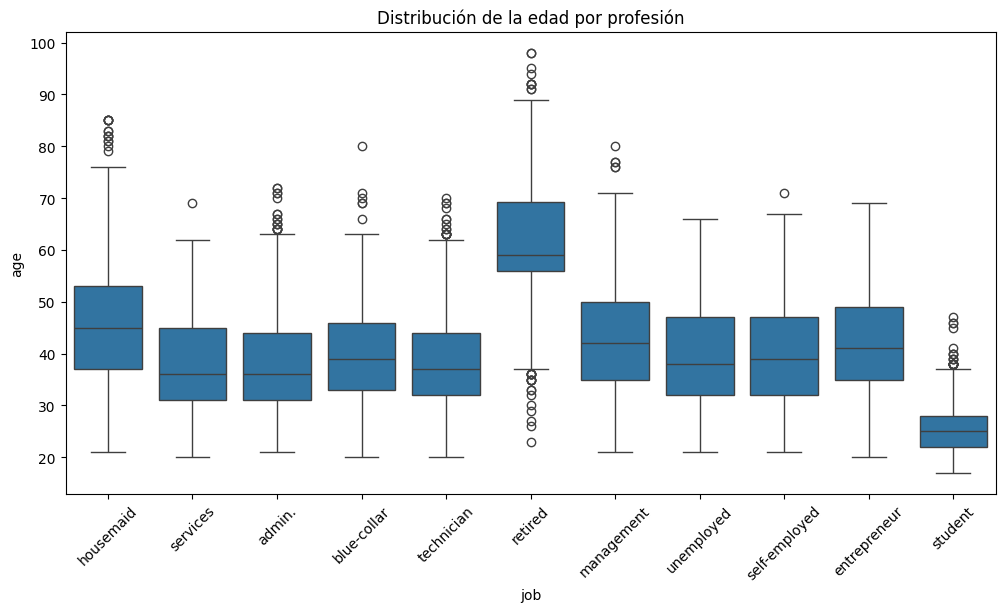

In [25]:
# Hacemos un gráfico de cajas (boxplot) para ver visualmente si los grupos difieren mucho:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_bank, x="job", y="age")
plt.xticks(rotation=45)
plt.title("Distribución de la edad por profesión")
plt.show()

Si que existe una relación fuerte entre job y age, especialmente en categorías extremas como student y retired.


1. Utilazaremos la **mediana** de **age** por cada job para rellenar los nulos.

    - Ejemplo: si un registro con job = "student" tiene la edad nula → se rellena con 25.

    - Si es retired → se rellena con 59 (la mediana).

2. Para los pocos casos en los que job también esté nulo, podemos:

    - Usar la mediana global de la edad (38 años).


De esta manera no forzamos un único valor (como 38 años) para todos los nulos, sino que adaptamos la imputación al perfil del cliente.

In [35]:
def impute_age_by_job(df, col_age='age', col_job='job', global_median=38):
    """
    Imputa los nulos de la columna `col_age` usando la mediana por `col_job`.
    Si `col_job` es nulo o no existe mediana para ese job, usa `global_median`.

    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame original.
    col_age : str
        Nombre de la columna edad (por defecto 'age').
    col_job : str
        Nombre de la columna job (por defecto 'job').
    global_median : int o float
        Mediana global a usar como fallback (por defecto 38 porque es la mediana para nuestro dataset).

    Devuelve:
    ---------
    df_filled : pd.DataFrame
        Copia del DataFrame con los nulos de `col_age` imputados.
    """
    # Hacemos copia para no modificar el original
    df_filled = df.copy()

    # Aseguramos que la columna age es numérica
    df_filled[col_age] = pd.to_numeric(df_filled[col_age])

    # Calculamos la mediana de age por job (usando solo filas con age no nulo)
    mediana_por_job = df_filled.groupby(col_job)[col_age].median()

    # Imputamos por job: map devolverá NaN si job es NaN o si no hay mediana para ese job
    df_filled[col_age] = df_filled[col_age].fillna(df_filled[col_job].map(mediana_por_job))

    # Para los que siguen siendo NaN (job nulo o job sin mediana), imputamos con la mediana global
    df_filled[col_age] = df_filled[col_age].fillna(global_median)

    # Convertimos a entero nullable (Int64) porque la edad es una variable entera
    df_filled[col_age] = df_filled[col_age].round().astype("Int64")

    return df_filled


In [39]:
# Calculamos mediana global de la edad
mediana_global_age = int(df_bank["age"].median())
mediana_global_age

df_bank_age_rellenado = impute_age_by_job(df_bank, col_age='age',
                                           col_job='job', global_median=mediana_global_age)

# Comprobaciones
print("Nulos antes:", df_bank['age'].isnull().sum())
print("Nulos después:", df_bank_age_rellenado['age'].isnull().sum())


Nulos antes: 5120
Nulos después: 0


## Nulos de eucation (4.20 %)

Dado que el porcentaje es bajo (4,2%) y se trata de una columna categórica, rellenamos los nulos con la categoría "unknown", de la misma forma que hicimos con 'default'.

In [43]:
# Rellenamos 'education' con 'unknown'
df_bank_education_rellenado = rellenar_con_unknown(df_bank, 'education')

# Verificamos
print(df_bank_education_rellenado['education'].isnull().sum())
print(df_bank_education_rellenado['education'].value_counts())

0
education
university.degree      12722
high.school             9925
basic.9y                6309
professional.course     5477
basic.4y                4356
basic.6y                2386
unknown                 1807
illiterate                18
Name: count, dtype: int64


### Creamos nuestro dataframe que contiene el manejo de todos los valores nulos de las distintas columnas

## Nulos de loan y housinb (2.39% en ambos casos)

Vamos a rellanar estas columas que en su esencia son de tipo booleana pero que ya contienen datos tipo object, así que crearemos otra categoría más, así tendremos {yes, no, unknown}

In [50]:
# Rellenamos 'loan' y 'housing con 'unknown'
df_bank_loan_housing_rellenado = rellenar_con_unknown(df_bank, 'loan')
df_bank_loan_housing_rellenado = rellenar_con_unknown(df_bank_loan_housing_rellenado, 'housing')

# Verificamos
print(df_bank_loan_housing_rellenado[['loan','housing']].isnull().sum())

loan       0
housing    0
dtype: int64


## Creamos función de manejo de nulos que iremos actualizando

In [51]:
def manejo_nulos(df):
    """
    Función general para manejar nulos en el DataFrame.
    
    Transformaciones:
    -----------------
    1. Rellena euribor3m con la media por fecha.
    2. Rellena la columna default con 'unknown'.
    3. (Opcional) Se pueden añadir más columnas categóricas a rellenar con 'unknown'.
    
    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame original con nulos.
    
    Devuelve:
    ---------
    df_clean : pd.DataFrame
        DataFrame con los nulos manejados y listo para análisis.
    """
    # Rellenamos 'euribor3m' con la media por fecha
    df_clean = rellenar_euribor3m_por_fecha(df)
    
    # Rellenamos 'default' con 'unknown'
    df_clean = rellenar_con_unknown(df_clean, 'default')

    # Rellenamos 'age' con la mediana por grupos y cuando el job es nulo
    # rellenamos con la mediana global = 38 años

    df_clean = impute_age_by_job(df_clean)

    # Rellenamos 'education' con 'unknown'
    df_clean = rellenar_con_unknown(df_clean, 'education')

    # Rellenamos 'loan' con 'unknown'
    df_clean = rellenar_con_unknown(df_clean, 'loan')

    # Rellenamos 'housing' con 'unknown'
    df_clean = rellenar_con_unknown(df_clean, 'housing')

        
    return df_clean


In [52]:
# Aplicar el manejo de nulos y guardar en dt_bank_sin_nulos
df_bank_sin_nulos = manejo_nulos(df_bank)

# Verificar que no quedan nulos en las columnas transformadas
print(df_bank_sin_nulos[['euribor3m', 'default', 'age','education','loan','housing']].isnull().sum())

euribor3m    57
default       0
age           0
education     0
loan          0
housing       0
dtype: int64


Para el resto de columnas la cantidad de nulos es < 1.1 % y decidimos no tratar estos valores

# Customer dataset

Guardamos en la carpeta de DataProcessed el archivo con el dataframe con los nulos tratados y controlados

In [54]:
df_bank_sin_nulos.to_csv("../Data/DataProcessed/bank-additional-clean-no-nulls.csv", index=False)
# Utilizamos index=False para evitar que se guarde la columna del índice como una columna extra en el CSV.